# Phần 1: Khởi tạo và Đọc dữ liệu

In [29]:
# 1. Import thư viện và đọc file
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Bạn có thể dùng thêm seaborn để biểu đồ đẹp hơn

df = pd.read_csv('ecommerce_sales_data.csv')

# 2. Hiển thị 7 dòng đầu và 5 dòng cuối
print("--- 7 dòng đầu tiên ---")
print(df.head(7))

print("\n--- 5 dòng cuối cùng ---")
print(df.tail(5))

# 3. Thông tin tổng quan cấu trúc dữ liệu
print("\n--- Thông tin cấu trúc dữ liệu ---")
df.info()

# 4. Thống kê mô tả cho các cột số
print("\n--- Thống kê mô tả ---")
print(df.describe())

--- 7 dòng đầu tiên ---
   OrderID        Date CustomerID Product_Category            Product_Name  \
0  ORD0001  2025-11-24    CUST027         Clothing                   Jeans   
1  ORD0002  2025-02-27    CUST025      Electronics              Smartphone   
2  ORD0003  2025-01-13    CUST025            Books  Machine Learning Intro   
3  ORD0004  2025-05-21    CUST002   Home & Kitchen            Coffee Maker   
4  ORD0005  2025-05-06    CUST008      Electronics                  Laptop   
5  ORD0006  2025-04-25    CUST027      Electronics                  Laptop   
6  ORD0007  2025-03-13    CUST002            Books   Data Science Handbook   

   Quantity  UnitPrice  Discount   Region  
0         6      93.20      0.12  Central  
1        10     134.67       NaN    South  
2         9     178.20      0.04    North  
3         3     199.86      0.01    North  
4         7     144.85      0.17    North  
5         3     138.23       NaN  Central  
6         1      71.97      0.04    South  

# Phần 2: Khám phá và Làm sạch dữ liệu

In [30]:
# 1. Kiểm tra số lượng giá trị thiếu (NaN/Null) ở mỗi cột
print("Số lượng giá trị thiếu trong từng cột:")
print(df.isnull().sum())

# 2. Xử lý giá trị thiếu ở cột Discount (thay bằng 0)
df['Discount'] = df['Discount'].fillna(0)

# 3. Xử lý giá trị thiếu ở cột CustomerID (thay bằng 'GUEST')
df['CustomerID'] = df['CustomerID'].fillna('GUEST')

# 4. Kiểm tra lại xem còn giá trị thiếu nào không
print("\nSố lượng giá trị thiếu sau khi xử lý:")
print(df.isnull().sum())

# 5. Chuyển đổi cột Date sang kiểu datetime
df['Date'] = pd.to_datetime(df['Date'])

# 6. Kiểm tra và loại bỏ dữ liệu trùng lặp toàn bộ
duplicate_count = df.duplicated().sum()
print(f"\nSố dòng trùng lặp phát hiện: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Đã loại bỏ các dòng trùng lặp.")

Số lượng giá trị thiếu trong từng cột:
OrderID              0
Date                 0
CustomerID           5
Product_Category     0
Product_Name         0
Quantity             0
UnitPrice            0
Discount            35
Region               0
dtype: int64

Số lượng giá trị thiếu sau khi xử lý:
OrderID             0
Date                0
CustomerID          0
Product_Category    0
Product_Name        0
Quantity            0
UnitPrice           0
Discount            0
Region              0
dtype: int64

Số dòng trùng lặp phát hiện: 0


# Phần 3: Trích xuất và Biến đổi dữ liệu (Feature Engineering)

In [31]:
# 1. Tạo cột Revenue (Doanh thu)
df['Revenue'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])

# 2. Trích xuất Năm (Year)
df['Year'] = df['Date'].dt.year

# 3. Trích xuất Tháng (Month)
df['Month'] = df['Date'].dt.month

# 4. Trích xuất Ngày trong tuần (Day of Week) - Ở đây dùng tên ngày cho trực quan
df['DayOfWeek'] = df['Date'].dt.day_name()

# 5. Tạo cột phân loại Price_Segment dựa trên UnitPrice
def classify_price(price):
    if price >= 150:
        return 'High'
    elif 50 <= price < 150:
        return 'Medium'
    else:
        return 'Low'

df['Price_Segment'] = df['UnitPrice'].apply(classify_price)

# Phần 4: Lọc và Truy vấn dữ liệu

In [32]:
# 1. Lọc đơn hàng khu vực 'North' và Revenue > 300
north_high_rev = df[(df['Region'] == 'North') & (df['Revenue'] > 300)]
print("Đơn hàng khu vực 'North' có Revenue > 300:")
print(north_high_rev)

# 2. Đếm đơn hàng 'Electronics' và Discount == 0
electronics_no_discount = df[(df['Product_Category'] == 'Electronics') & (df['Discount'] == 0)]
print(f"\nSố đơn hàng Electronics không giảm giá: {len(electronics_no_discount)}")

# 3. Đơn hàng từ tháng 3 đến tháng 6
march_to_june_orders = df[df['Month'].isin([3, 4, 5, 6])]

# 4. Hiển thị 3 cột của top 10 đơn hàng có doanh thu cao nhất
top_10_revenue = df.nlargest(10, 'Revenue')[['OrderID', 'Product_Name', 'Revenue']]
print("\nTop 10 đơn hàng doanh thu cao nhất:")
print(top_10_revenue)

# 5. Chi tiết đơn hàng có số lượng (Quantity) mua nhiều nhất
max_quantity_order = df[df['Quantity'] == df['Quantity'].max()]
print("\nĐơn hàng có số lượng mua nhiều nhất:")
print(max_quantity_order)

Đơn hàng khu vực 'North' có Revenue > 300:
    OrderID       Date CustomerID Product_Category              Product_Name  \
2   ORD0003 2025-01-13    CUST025            Books    Machine Learning Intro   
3   ORD0004 2025-05-21    CUST002   Home & Kitchen              Coffee Maker   
4   ORD0005 2025-05-06    CUST008      Electronics                    Laptop   
25  ORD0026 2025-10-07      GUEST            Books     Data Science Handbook   
31  ORD0032 2025-01-04    CUST018      Electronics                Headphones   
33  ORD0034 2025-12-24    CUST009      Electronics                Headphones   
36  ORD0037 2025-05-23    CUST014      Electronics                   Monitor   
37  ORD0038 2025-03-21    CUST029      Electronics                Smartphone   
44  ORD0045 2025-07-03    CUST016         Clothing                   T-Shirt   
45  ORD0046 2025-06-26    CUST003            Books  Python for Data Analysis   
51  ORD0052 2025-03-05    CUST021   Home & Kitchen              Coffee Maker 

# Phần 5: Phân tích, Gom nhóm và Tổng hợp

In [33]:
# 1. Nhóm theo Region và tính tổng Revenue
region_revenue = df.groupby('Region')['Revenue'].sum()
print("Doanh thu theo từng khu vực:")
print(region_revenue)
print(f"--> Khu vực mang lại doanh thu cao nhất là: {region_revenue.idxmax()} với {region_revenue.max():,.2f}")

# 2. Tính trung bình Quantity và UnitPrice theo Product_Category
category_stats = df.groupby('Product_Category')[['Quantity', 'UnitPrice']].mean()
print("\nTrung bình số lượng và đơn giá theo danh mục:")
print(category_stats)

# 3. Thống kê tổng số lượng đơn hàng theo từng tháng
monthly_order_count = df.groupby('Month')['OrderID'].count()
print("\nSố lượng đơn hàng theo từng tháng:")
print(monthly_order_count)
print(f"--> Tháng có nhiều đơn hàng nhất là tháng: {monthly_order_count.idxmax()}")

# 4. Top 3 khách hàng chi tiêu nhiều nhất (Loại trừ 'GUEST')
top_3_customers = df[df['CustomerID'] != 'GUEST'].groupby('CustomerID')['Revenue'].sum().nlargest(3)
print("\nTop 3 khách hàng chịu chi nhất:")
print(top_3_customers)

Doanh thu theo từng khu vực:
Region
Central    30679.9509
North      23579.3016
South      18995.3702
Name: Revenue, dtype: float64
--> Khu vực mang lại doanh thu cao nhất là: Central với 30,679.95

Trung bình số lượng và đơn giá theo danh mục:
                  Quantity   UnitPrice
Product_Category                      
Books             5.071429  124.435000
Clothing          5.321429  167.446786
Electronics       5.551724  166.513103
Home & Kitchen    4.620690  141.211724

Số lượng đơn hàng theo từng tháng:
Month
1      7
2     12
3      7
4     11
5     11
6      4
7      9
8      7
9      1
10    10
11    11
12    10
Name: OrderID, dtype: int64
--> Tháng có nhiều đơn hàng nhất là tháng: 2

Top 3 khách hàng chịu chi nhất:
CustomerID
CUST025    5505.3496
CUST004    5033.4404
CUST017    4553.5066
Name: Revenue, dtype: float64


# Phần 6: Trực quan hóa dữ liệu cơ bản

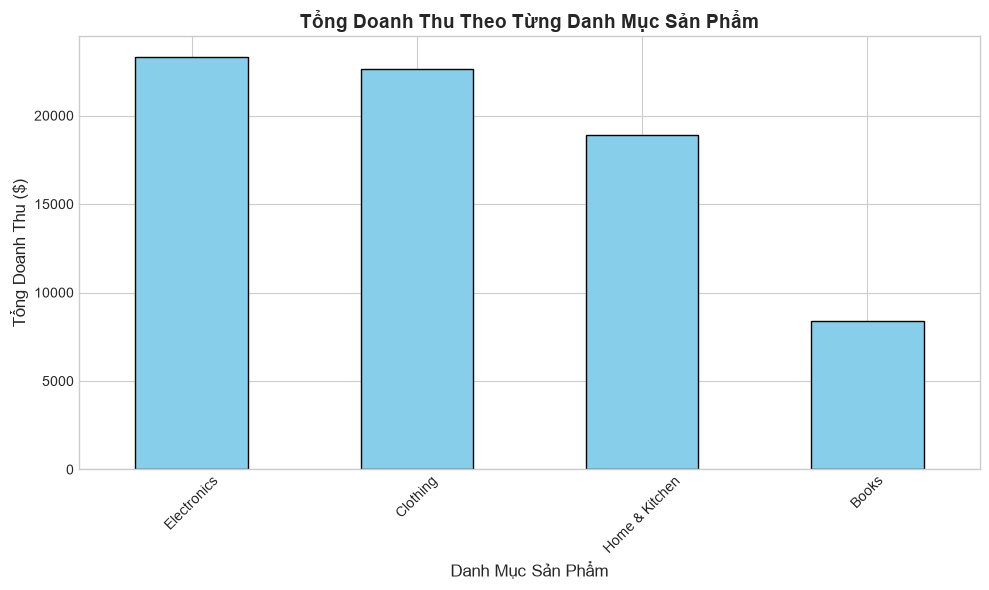

In [34]:
# Thiết kế chung cho biểu đồ đẹp hơn
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Biểu đồ cột: Tổng doanh thu theo từng Danh mục sản phẩm
plt.figure(figsize=(10, 6))
cat_revenue = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)
cat_revenue.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Tổng Doanh Thu Theo Từng Danh Mục Sản Phẩm', fontsize=14, fontweight='bold')
plt.xlabel('Danh Mục Sản Phẩm', fontsize=12)
plt.ylabel('Tổng Doanh Thu ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



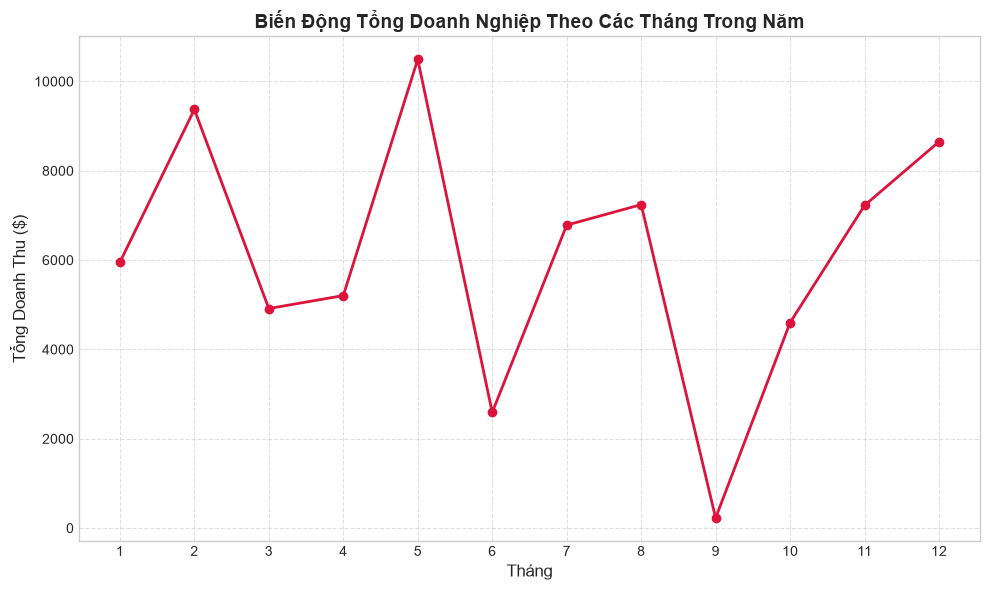

In [35]:
# Thiết kế chung cho biểu đồ đẹp hơn
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
# 2. Biểu đồ đường: Sự biến động của tổng doanh thu qua các tháng
plt.figure(figsize=(10, 6))
monthly_rev = df.groupby('Month')['Revenue'].sum()
plt.plot(monthly_rev.index, monthly_rev.values, marker='o', linestyle='-', color='crimson', linewidth=2)
plt.title('Biến Động Tổng Doanh Nghiệp Theo Các Tháng Trong Năm', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tổng Doanh Thu ($)', fontsize=12)
plt.xticks(monthly_rev.index) # Hiển thị rõ các tháng 1, 2, 3...
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()